# Tag-only baseline: binary tag features + gradient-boosted trees

**Idea:** each recipe = a binary vector over its (frequent) tags. A tree model learns `P(user liked recipe | tags)`,
and that probability is the recipe's score. No user or recipe embeddings.

**Decisions taken from the EDA**
- Rating `0` (~5% of rows) is dropped, not treated as a dislike.
- 73% of users have exactly one interaction, so per-user models are impossible. This baseline is a single *global* model, and every user gets the same ranking.
- Ratings are 72% five-star, so the positive threshold matters (`>=4` gives ~94% positives, `==5` gives ~76%).
- Split is **temporal** (train on the past, test on the future), which also covers users with a single interaction.
- Text (`review`) is not loaded, which saves about half the RAM.

In [ ]:
import json, os, re, runpy, subprocess, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss
from sklearn.preprocessing import MultiLabelBinarizer
import lightgbm as lgb   # preinstalled on Colab

SEED = 42

# ---------------- data setup ----------------
REPO_URL = "https://github.com/mihikabairathi/ml_in_practice_project"

if "google.colab" in sys.modules:
    REPO = Path("/content/ml_in_practice_project")
    if not REPO.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(REPO)], check=True)
    sys.path.insert(0, str(REPO / "src"))     # makes `import remy` work

from remy.paths import PROJECT_ROOT
RAW = PROJECT_ROOT / "data" / "raw"
FILES = ["recipes.parquet", "interactions.parquet"]

if not all((RAW / f).exists() for f in FILES):
    os.chdir(PROJECT_ROOT)                    # the script expects to run from the repo root
    runpy.run_path(str(PROJECT_ROOT / "scripts" / "download_data.py"), run_name="__main__")

DATA = RAW
print("data ready:", [f"{f} ({(DATA / f).stat().st_size / 1e6:.0f} MB)" for f in FILES])

data ready: ['recipes.parquet (112 MB)', 'interactions.parquet (195 MB)']


## 1. Load data and build the binary label

In [ ]:
recipes = pd.read_parquet(DATA / "recipes.parquet", columns=["id", "name", "tags"])
interactions = pd.read_parquet(DATA / "interactions.parquet", columns=["user_id", "recipe_id", "date", "rating"])

# recipe id -> row position (used to index the feature matrix)
row_of = pd.Series(np.arange(len(recipes)), index=recipes["id"])
n_items = len(recipes)
interactions["ridx"] = row_of.reindex(interactions["recipe_id"]).to_numpy()
assert interactions["ridx"].notna().all()          # EDA: 0 unmatched recipe references
interactions["ridx"] = interactions["ridx"].astype("int64")

POS_THRESHOLD = 5    # 5 = "loved it". Try 4 for "liked it" (but ~94% of rows become positive)

rated = interactions[interactions["rating"] > 0].copy()   # 0 = no star rating, not a dislike
rated["label"] = (rated["rating"] >= POS_THRESHOLD).astype("int8")
print(f"rated rows: {len(rated):,}   positive rate: {rated['label'].mean():.1%}")

rated rows: 1,071,520   positive rate: 76.2%


## 2. Temporal split (80 / 10 / 10 by date)

In [ ]:
t_val, t_test = rated["date"].quantile([0.8, 0.9])
train = rated[rated["date"] < t_val]
val   = rated[(rated["date"] >= t_val) & (rated["date"] < t_test)]
test  = rated[rated["date"] >= t_test]

print(f"train {len(train):,} | val {len(val):,} | test {len(test):,}")
print(f"split dates: val from {t_val.date()}, test from {t_test.date()}")
print(f"test rows whose user is unseen in train: {(~test['user_id'].isin(train['user_id'])).mean():.1%}")
print(f"test rows whose recipe is unseen in train: {(~test['ridx'].isin(train['ridx'])).mean():.1%}  (a tag model can still score these)")

train 857,164 | val 107,176 | test 107,180
split dates: val from 2011-09-19, test from 2013-10-24
test rows whose user is unseen in train: 70.4%
test rows whose recipe is unseen in train: 19.1%  (a tag model can still score these)


## 3. Binary tag features

In [ ]:
MIN_TAG_COUNT = 100     # drop very rare tags: fewer features and less overfitting

tag_counts = recipes["tags"].explode().value_counts()      # counted over the recipe catalogue, not labels: no leakage
vocab = [str(t) for t in tag_counts[tag_counts >= MIN_TAG_COUNT].index]
vocab_set = set(vocab)
print(f"{len(tag_counts)} distinct tags -> keeping {len(vocab)} with >= {MIN_TAG_COUNT} recipes")

mlb = MultiLabelBinarizer(classes=vocab, sparse_output=True)
X_recipe = (
    mlb.fit_transform([[t for t in tags if t in vocab_set] for tags in recipes["tags"]])
    .astype(np.float32)
    .tocsr()
)
print("recipe x tag matrix:", X_recipe.shape, f"density {X_recipe.nnz / np.prod(X_recipe.shape):.1%}")
print(tag_counts.head(15).to_string())

552 distinct tags -> keeping 412 with >= 100 recipes
recipe x tag matrix: (231637, 412) density 4.3%
tags
preparation           230546
time-to-make          225326
course                218148
main-ingredient       170446
dietary               165091
easy                  126062
occasion              114145
cuisine                91165
low-in-something       85776
main-dish              71786
equipment              70436
60-minutes-or-less     69990
number-of-servings     58949
meat                   56042
30-minutes-or-less     55077


## 4. Train the tree model

Every recipe has many tags, so a tag combination can almost identify one recipe. To stop the trees memorising individual recipes, they are kept small (`num_leaves`), leaves need many rows (`min_child_samples`), and training uses early stopping on the validation period.

`fit_lgbm(cols)` takes a subset of tag columns so the same code can train the image-compatible variant later.

In [ ]:
PARAMS = dict(
    objective="binary",
    metric=["auc", "binary_logloss"],   # early stopping follows the first one (AUC)
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=200,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    lambda_l2=10.0,
    seed=SEED,
    verbose=-1,
)

def fit_lgbm(cols):
    """Train on the given tag columns. Returns (model, score_for_every_recipe)."""
    Xr = X_recipe[:, cols].tocsr()
    dtrain = lgb.Dataset(Xr[train["ridx"].to_numpy()], train["label"].to_numpy())
    dval = lgb.Dataset(Xr[val["ridx"].to_numpy()], val["label"].to_numpy(), reference=dtrain)
    model = lgb.train(
        PARAMS, dtrain, num_boost_round=2000, valid_sets=[dval],
        callbacks=[lgb.early_stopping(50, first_metric_only=True), lgb.log_evaluation(50)],
    )
    return model, model.predict(Xr, num_iteration=model.best_iteration)

all_cols = np.arange(len(vocab))
model_all, scores_all = fit_lgbm(all_cols)

Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.564619	valid_0's binary_logloss: 0.521592
[100]	valid_0's auc: 0.570775	valid_0's binary_logloss: 0.52037
[150]	valid_0's auc: 0.573886	valid_0's binary_logloss: 0.519814
[200]	valid_0's auc: 0.576167	valid_0's binary_logloss: 0.51941
[250]	valid_0's auc: 0.577718	valid_0's binary_logloss: 0.519092
[300]	valid_0's auc: 0.578859	valid_0's binary_logloss: 0.518872
[350]	valid_0's auc: 0.57978	valid_0's binary_logloss: 0.518689
[400]	valid_0's auc: 0.58049	valid_0's binary_logloss: 0.51855
[450]	valid_0's auc: 0.581279	valid_0's binary_logloss: 0.518395
[500]	valid_0's auc: 0.582177	valid_0's binary_logloss: 0.518229
[550]	valid_0's auc: 0.582675	valid_0's binary_logloss: 0.518133
[600]	valid_0's auc: 0.583579	valid_0's binary_logloss: 0.517957
[650]	valid_0's auc: 0.584024	valid_0's binary_logloss: 0.517851
[700]	valid_0's auc: 0.584525	valid_0's binary_logloss: 0.517751
[750]	valid_0's auc: 0.584871	valid

## 5. Evaluate

**Pointwise**: how well does the score separate liked from not-liked interactions in the test period?

**Ranking**: for each test positive, rank it among 99 random recipes the user hasn't interacted with (sampled-negatives protocol; every method sees identical candidates). Two references are included:
- *Random*: the floor.
- *Popularity*: train-period interaction counts, the standard sanity check. The tag model should be judged against this.


Idea: across all test-period ratings, do recipes the model scored higher tend to be the ones people actually rated 5 stars? It checks whether the scores mean anything, without any ranking.

Result: AUC 0.57 and logloss 0.5459 vs 0.5509 for a lazy "everyone gets 76%" guess.
AUC: Chance a loved recipe scored higher than a not-loved one	Do the tags separate what people love from what they don't? 0.5 is a coin flip

Logloss	Penalty: for confident wrong predictions (lower is better)	Are the scores well calibrated as probabilities?

PR-AUC:	Ranking quality focused on the loved class	Because most ratings are 5 stars, a no-skill model scores roughly the share of 5-star ratings (about 0.76 if the test period resembles training)	0.802


Tags alone carry a real but weak signal about whether a recipe gets loved. This is the cell that shows how weak.


In [ ]:
# across all test ratings, do higher scores line up with "loved it"?
y_train_mean = train["label"].mean()

def pointwise(scores, df):
    p = np.clip(scores[df["ridx"].to_numpy()], 1e-6, 1 - 1e-6)
    y = df["label"].to_numpy()
    return {
        "AUC": roc_auc_score(y, p),
        "PR-AUC": average_precision_score(y, p),
        "logloss": log_loss(y, p),
        "logloss (predict train mean)": log_loss(y, np.full_like(p, y_train_mean)),
    }

print(pd.Series(pointwise(scores_all, test)).round(4).to_string())

AUC                             0.5691
PR-AUC                          0.8020
logloss                         0.5459
logloss (predict train mean)    0.5509


Idea: this simulates the product. For each real "user loved recipe X" case in the test period, we build a lineup of X plus 99 random recipes the user never rated. Then we see where each method places X: Random (shuffle), Popularity (past review counts), and the tree model (tag scores). The metrics (HR@10, NDCG@10, sampled AUC) all measure how close to the top X lands.

Result: the tree model beats random (HR@10 0.178 vs 0.113) but loses badly to popularity (0.496).

HR@10:	How often the loved recipe is in the top 10 of 100	If we showed a shortlist, how often would it contain something they'd love?

NDCG@10	Like HR, but landing at #1 counts more than #10	Position matters: users look at the top of a list first

Sampled AUC	Average fraction of decoys the loved recipe beats	A cutoff-free view of ranking quality. 0.5 is chance


For the project:
Popularity is the bar for the ML system to beat, and this baseline doesn't clear it.

The gap is partly a test artifact. Loved recipes were reviewed by definition, and the random decoys are mostly obscure, so review count nearly gives the answer away. This is your Q10 exposure-bias risk.
Because of that, these sampled numbers should not go in the final report. Switch to ranking against the full catalog.


In [ ]:
N_EVAL, N_NEG, K = 20_000, 99, 10

# --- candidate sets: 1 held-out positive + 99 unseen random recipes ---
eval_pos = test[test["label"] == 1]
eval_pos = eval_pos.sample(min(N_EVAL, len(eval_pos)), random_state=SEED)
seen = (
    interactions[interactions["user_id"].isin(set(eval_pos["user_id"]))]
    .groupby("user_id")["ridx"].agg(set)          # everything the user ever interacted with
)

rng = np.random.default_rng(SEED)
cands = np.empty((len(eval_pos), N_NEG + 1), dtype=np.int64)
for i, (u, pos) in enumerate(zip(eval_pos["user_id"].to_numpy(), eval_pos["ridx"].to_numpy())):
    s, negs = seen[u], set()
    while len(negs) < N_NEG:
        for c in rng.integers(n_items, size=N_NEG):
            if int(c) not in s:
                negs.add(int(c))
            if len(negs) == N_NEG:
                break
    cands[i, 0], cands[i, 1:] = pos, list(negs)

def rank_metrics(scores, k=K):
    s = scores[cands]
    pos, neg = s[:, [0]], s[:, 1:]
    rank = 1 + (neg > pos).sum(1) + 0.5 * (neg == pos).sum(1)     # ties count half
    hit = rank <= k
    return {
        f"HR@{k}": hit.mean(),
        f"NDCG@{k}": np.where(hit, 1 / np.log2(rank + 1), 0).mean(),
        "sampled AUC": (1 - (rank - 1) / N_NEG).mean(),
    }

popularity = np.bincount(train["ridx"], minlength=n_items).astype(float)
random_scores = np.random.default_rng(SEED).random(n_items)

results = {
    "Random": rank_metrics(random_scores),
    "Popularity (train counts)": rank_metrics(popularity),
    "Tags -> LightGBM (all tags)": rank_metrics(scores_all),
}
pd.DataFrame(results).T.round(4)

,HR@10,NDCG@10,sampled AUC
Random,0.1134,0.0560,0.5142
Popularity (train counts),0.4956,0.3495,0.6990
Tags -> LightGBM (all tags),0.1779,0.0955,0.5738


## 6. What did the model learn?
Idea: a sanity check, not a score. It shows which tags the model leans on most, and which recipes it scores highest and lowest.

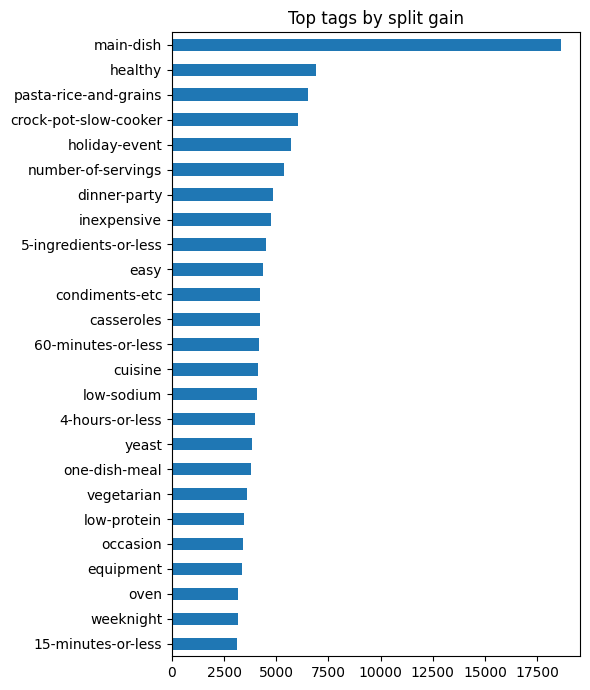

,name,score
127192,low fat raspberry brownies for 1 or 2,0.300771
65409,crock pot breakfast apple cobbler,0.321078
146338,oatmeal raisin breakfast cookies,0.332785
45408,chicken rice salad,0.350305
70236,decadent fat free chocolate treat,0.359721


,name,score
171499,rays of sunshine homemade candied orange peel,0.948254
137091,mixed spice traditional old fashioned engli...,0.951354
94133,good eats roast turkey,0.952833
129662,mango salsa 1,0.954833
219839,uncle bill s method for cooking turkey,0.963894


In [ ]:
imp = pd.Series(model_all.feature_importance("gain"), index=vocab).sort_values(ascending=False)
imp.head(25).iloc[::-1].plot.barh(figsize=(6, 7), title="Top tags by split gain")
plt.tight_layout(); plt.show()

# Best / worst recipes by score, as a sanity check
view = recipes[["name"]].assign(score=scores_all).sort_values("score")
display(view.head(5)); display(view.tail(5))

The tree model performs in between random and popularity

AUC: how well the tree can separate 5 stars from non 5 stars (56%)

ranking test: when user gave a recipe 5 stars in the test set, combined that recipe with 99 recipes the user never rated to see how the model would rank that 5 star recipe
- HR@10 = how often it lands in the top 10 (random = 0.10, popular ~ 50%, tree ~ 18%)
 - NDCG@10 = same idea, but landing at #1 counts more than #10 (random = 5%, popular ~35%, tree ~ 10%)
  - Sampled AUC = avg share of 99 random recipes that it beats (random = 0.5, popular ~ 70%, tree ~ 57%)
